# Ramer Douglas Peucker (RDP) Algorithm

--> reduces the number of points in a curve that is approximated by a series of points

Events Shape: (32, 2)


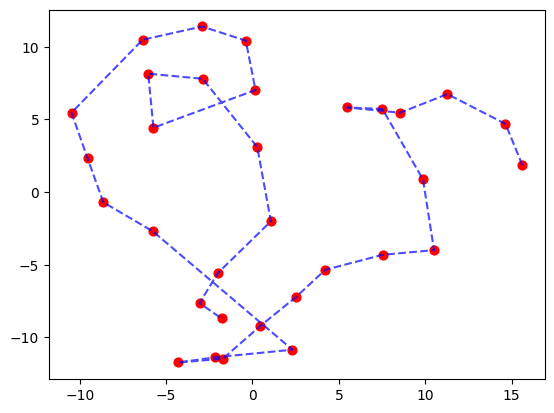

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Go to folder
os.chdir(r"C:\Users\Alishba\Downloads\prediction files\Transcriptions\Trajectory Analysis\k50 embeddings")

events = np.load("delayed-events.npy")
print('Events Shape:', events.shape)
plt.plot(events[:,0], events[:,1], color="blue", linestyle="--", alpha=0.7, label="Delayed Event Path")

# Add points for each event
plt.scatter(events[:, 0], events[:, 1], color="red", s=40, label="Events")

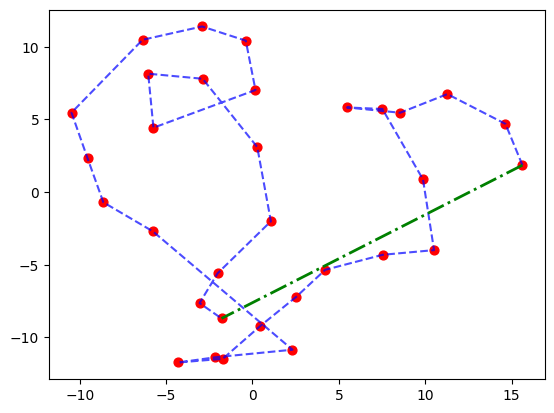

In [7]:
plt.plot(events[:,0], events[:,1], color="blue", linestyle="--", alpha=0.7, label="Delayed Event Path")

# Add points for each event
plt.scatter(events[:, 0], events[:, 1], color="red", s=40, label="Events")

# Line from first to last event
plt.plot([events[0,0], events[-1,0]], [events[0,1], events[-1,1]],
         color="green", linestyle="-.", linewidth=2, label="Start→End")

Perpendicular Distances: [ 0.          2.93762681  6.43539868  6.75304277  8.65719911  7.50579305
  2.14054704  2.35134519  1.08439676  0.24666457  0.96822325  1.60742048
  2.41394471  1.29222543  2.1041316   3.96939518  7.18189549 10.38040161
 13.43847804 16.61207374 18.77001576 17.77040272 15.62431895 12.42776055
 13.26842141 16.60575603 14.67412428  9.01833035  4.23787078  2.77739495
  1.56337593  0.        ]
Farthest Point: [-6.35968235 10.48189215], Distance: 18.77001575632038, Event #: 20


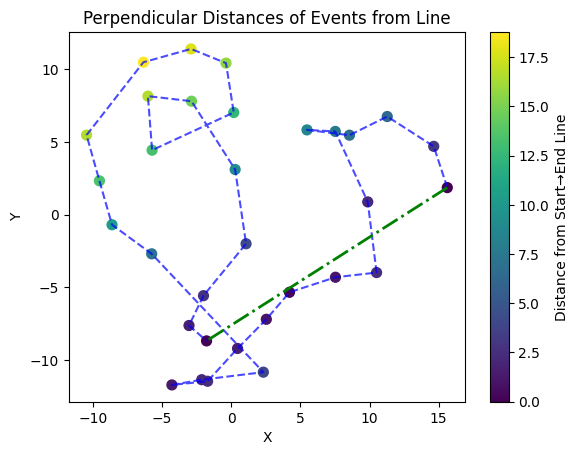

In [14]:
# First and last points
x1, y1 = events[0]
x2, y2 = events[-1]

# Calculate perpendicular distances
distances = []
for (x0, y0) in events:
    d = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    distances.append(d)

distances = np.array(distances)
print("Perpendicular Distances:", distances)

# Find farthest point
farthest_idx = np.argmax(distances)
farthest_point = events[farthest_idx]
print(f"Farthest Point: {farthest_point}, Distance: {distances[farthest_idx]}, Event #: {farthest_idx}")

# Plot trajectory
plt.plot(events[:, 0], events[:, 1], color="blue", linestyle="--", alpha=0.7, label="Delayed Event Path")

# Add points
plt.scatter(events[:, 0], events[:, 1], c=distances, cmap="viridis", s=50, label="Events (colored by distance)")

# Line from first to last
plt.plot([x1, x2], [y1, y2], color="green", linestyle="-.", linewidth=2, label="Start→End")

plt.colorbar(label="Distance from Start→End Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Perpendicular Distances of Events from Line")
plt.show()


### Ramer Douglas Peucker Algorithm - Compelete Implementation for Delayed events

Events Shape: (32, 2)

=== STEP 1: Initial Analysis ===
Initial farthest point: Event #20, Distance: 18.7700

=== STEP 2: Visualizing the Split ===


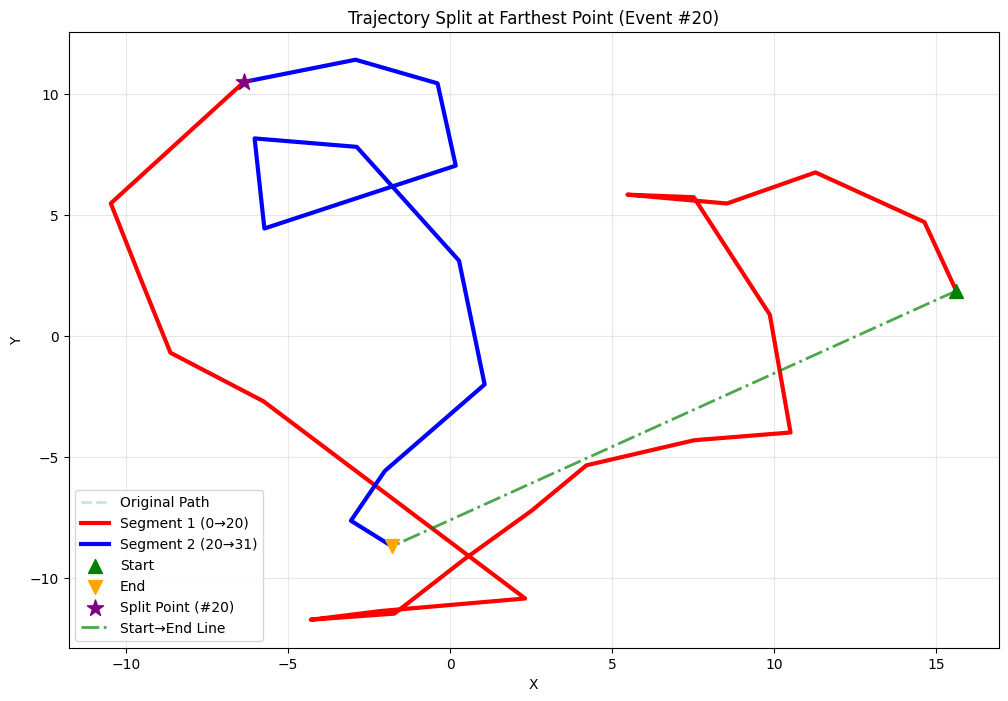


=== STEP 3: Applying RDP Recursively ===
Using epsilon = 0.1 * max_distance = 1.8770
Processing segment: 0 to 31
  Farthest point: 20, Distance: 18.7700, Epsilon: 1.8770
  Keeping point 20
Processing segment: 0 to 20
  Farthest point: 13, Distance: 19.9208, Epsilon: 1.8770
  Keeping point 13
Processing segment: 0 to 13
  Farthest point: 4, Distance: 8.9997, Epsilon: 1.8770
  Keeping point 4
Processing segment: 0 to 4
  Farthest point: 2, Distance: 2.9726, Epsilon: 1.8770
  Keeping point 2
Processing segment: 0 to 2
  Farthest point: 1, Distance: 1.1519, Epsilon: 1.8770
  No points to keep in this segment
Processing segment: 2 to 4
  Farthest point: 3, Distance: 0.8409, Epsilon: 1.8770
  No points to keep in this segment
Processing segment: 4 to 13
  Farthest point: 7, Distance: 9.1767, Epsilon: 1.8770
  Keeping point 7
Processing segment: 4 to 7
  Farthest point: 5, Distance: 1.7736, Epsilon: 1.8770
  No points to keep in this segment
Processing segment: 7 to 13
  Farthest point: 9, D

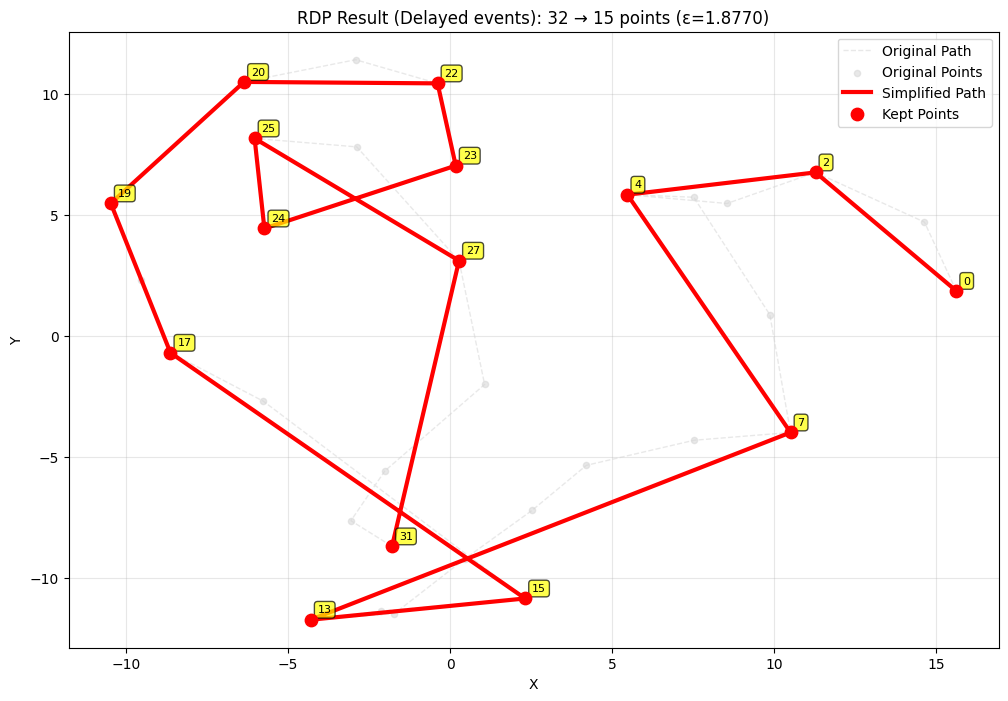


Summary:
- Original trajectory had 32 points
- RDP simplified it to 15 points
- Kept event indices: [0, 2, 4, 7, 13, 15, 17, 19, 20, 22, 23, 24, 25, 27, 31]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Go to folder
os.chdir(r"C:\Users\Alishba\Downloads\prediction files\Transcriptions\Trajectory Analysis\k50 embeddings")
events = np.load("delayed-events.npy")
print('Events Shape:', events.shape)

def calculate_perpendicular_distance(point, line_start, line_end):
    """Calculate perpendicular distance from point to line"""
    x0, y0 = point
    x1, y1 = line_start
    x2, y2 = line_end
    
    # Handle case where line_start and line_end are the same
    if x1 == x2 and y1 == y2:
        return np.sqrt((x0-x1)**2 + (y0-y1)**2)
    
    distance = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    return distance

def find_farthest_point(points, start_idx, end_idx):
    """Find the point farthest from the line between start and end points"""
    if end_idx - start_idx <= 1:
        return -1, 0
    
    line_start = points[start_idx]
    line_end = points[end_idx]
    
    max_distance = 0
    farthest_idx = -1
    
    for i in range(start_idx + 1, end_idx):
        distance = calculate_perpendicular_distance(points[i], line_start, line_end)
        if distance > max_distance:
            max_distance = distance
            farthest_idx = i
    
    return farthest_idx, max_distance

def rdp_recursive(points, start_idx, end_idx, epsilon, kept_indices):
    """Recursive RDP algorithm"""
    print(f"Processing segment: {start_idx} to {end_idx}")
    
    # Find farthest point
    farthest_idx, max_distance = find_farthest_point(points, start_idx, end_idx)
    
    print(f"  Farthest point: {farthest_idx}, Distance: {max_distance:.4f}, Epsilon: {epsilon:.4f}")
    
    # If distance is greater than epsilon, keep the point and recurse
    if farthest_idx != -1 and max_distance > epsilon:
        print(f"  Keeping point {farthest_idx}")
        kept_indices.append(farthest_idx)
        
        # Recursively process the two segments
        rdp_recursive(points, start_idx, farthest_idx, epsilon, kept_indices)
        rdp_recursive(points, farthest_idx, end_idx, epsilon, kept_indices)
    else:
        print(f"  No points to keep in this segment")

# Step 1: Find the initial farthest point 
print("\n=== STEP 1: Initial Analysis ===")
x1, y1 = events[0]
x2, y2 = events[-1]

distances = []
for (x0, y0) in events:
    d = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    distances.append(d)
distances = np.array(distances)

farthest_idx = np.argmax(distances)
max_distance = distances[farthest_idx]
print(f"Initial farthest point: Event #{farthest_idx}, Distance: {max_distance:.4f}")

# Step 2: Visualize the split
print("\n=== STEP 2: Visualizing the Split ===")
plt.figure(figsize=(12, 8))

# Plot original trajectory
plt.plot(events[:, 0], events[:, 1], color="lightblue", linestyle="--", alpha=0.7, linewidth=2, label="Original Path")

# Plot the two segments after split
segment1 = events[:farthest_idx+1]
segment2 = events[farthest_idx:]

plt.plot(segment1[:, 0], segment1[:, 1], color="red", linewidth=3, label=f"Segment 1 (0→{farthest_idx})")
plt.plot(segment2[:, 0], segment2[:, 1], color="blue", linewidth=3, label=f"Segment 2 ({farthest_idx}→{len(events)-1})")

# Highlight key points
plt.scatter(events[0, 0], events[0, 1], color="green", s=100, marker="^", label="Start", zorder=5)
plt.scatter(events[-1, 0], events[-1, 1], color="orange", s=100, marker="v", label="End", zorder=5)
plt.scatter(events[farthest_idx, 0], events[farthest_idx, 1], color="purple", s=150, marker="*", label=f"Split Point (#{farthest_idx})", zorder=5)

# Original line from start to end
plt.plot([x1, x2], [y1, y2], color="green", linestyle="-.", linewidth=2, alpha=0.7, label="Start→End Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Trajectory Split at Farthest Point (Event #{farthest_idx})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 3: Apply RDP recursively
print("\n=== STEP 3: Applying RDP Recursively ===")
epsilon = 0.1 * max_distance
print(f"Using epsilon = 0.1 * max_distance = {epsilon:.4f}")

# Keep track of indices that we want to preserve
kept_indices = [0, len(events)-1]  # Always keep start and end points

# Apply RDP recursively
rdp_recursive(events, 0, len(events)-1, epsilon, kept_indices)

# Sort the kept indices
kept_indices.sort()
print(f"\nFinal kept indices: {kept_indices}")
print(f"Original points: {len(events)}, Simplified points: {len(kept_indices)}")
print(f"Compression ratio: {len(kept_indices)/len(events)*100:.1f}%")

# Step 4: Visualize the final result
print("\n=== STEP 4: Final Result ===")
plt.figure(figsize=(12, 8))

# Plot original trajectory
plt.plot(events[:, 0], events[:, 1], color="lightgray", linestyle="--", alpha=0.5, linewidth=1, label="Original Path")
plt.scatter(events[:, 0], events[:, 1], color="lightgray", s=20, alpha=0.5, label="Original Points")

# Plot simplified trajectory
simplified_events = events[kept_indices]
plt.plot(simplified_events[:, 0], simplified_events[:, 1], color="red", linewidth=3, label="Simplified Path")
plt.scatter(simplified_events[:, 0], simplified_events[:, 1], color="red", s=80, label="Kept Points", zorder=5)

# Annotate kept points with their original indices
for i, idx in enumerate(kept_indices):
    plt.annotate(f'{idx}', (events[idx, 0], events[idx, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"RDP Result (Delayed events): {len(events)} → {len(kept_indices)} points (ε={epsilon:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nSummary:")
print(f"- Original trajectory had {len(events)} points")
print(f"- RDP simplified it to {len(kept_indices)} points")
print(f"- Kept event indices: {kept_indices}")

### Ramer Douglas Peucker Algorithm - Compelete Implementation for Original Episode events

Events Shape: (32, 2)

=== STEP 1: Initial Analysis ===
Initial farthest point: Event #22, Distance: 16.6436

=== STEP 2: Visualizing the Split ===


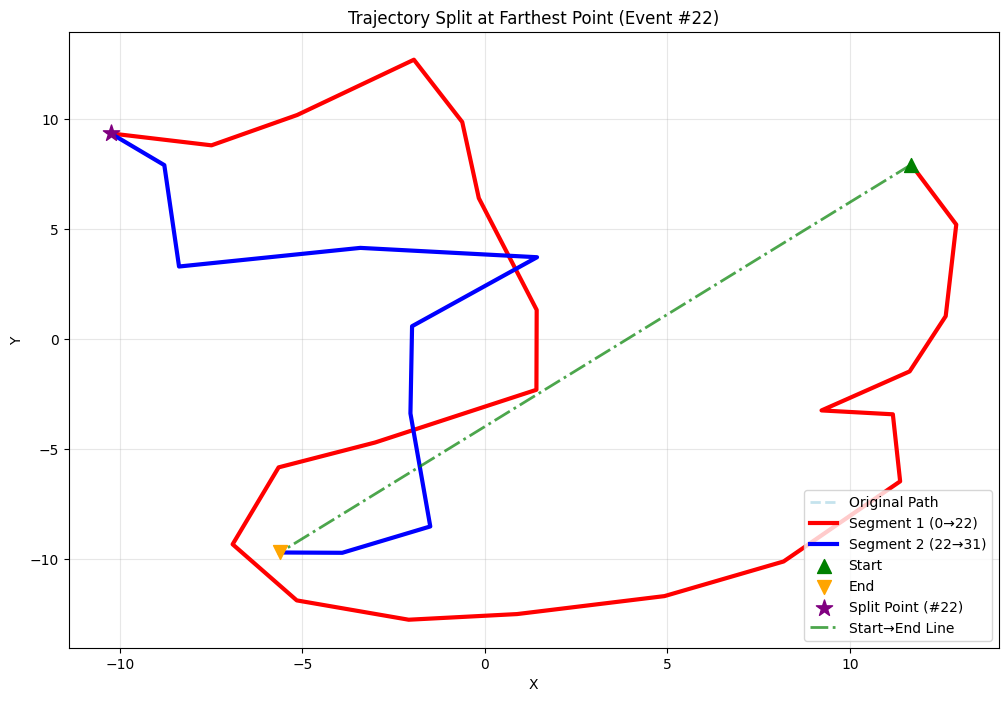


=== STEP 3: Applying RDP Recursively ===
Using epsilon = 0.1 * max_distance = 1.6644
Processing segment: 0 to 31
  Farthest point: 22, Distance: 16.6436, Epsilon: 1.6644
  Keeping point 22
Processing segment: 0 to 22
  Farthest point: 10, Distance: 21.5220, Epsilon: 1.6644
  Keeping point 10
Processing segment: 0 to 10
  Farthest point: 6, Distance: 7.7235, Epsilon: 1.6644
  Keeping point 6
Processing segment: 0 to 6
  Farthest point: 4, Distance: 2.2218, Epsilon: 1.6644
  Keeping point 4
Processing segment: 0 to 4
  Farthest point: 2, Distance: 2.4027, Epsilon: 1.6644
  Keeping point 2
Processing segment: 0 to 2
  Farthest point: 1, Distance: 0.8519, Epsilon: 1.6644
  No points to keep in this segment
Processing segment: 2 to 4
  Farthest point: 3, Distance: 0.7878, Epsilon: 1.6644
  No points to keep in this segment
Processing segment: 4 to 6
  Farthest point: 5, Distance: 1.5267, Epsilon: 1.6644
  No points to keep in this segment
Processing segment: 6 to 10
  Farthest point: 8, Di

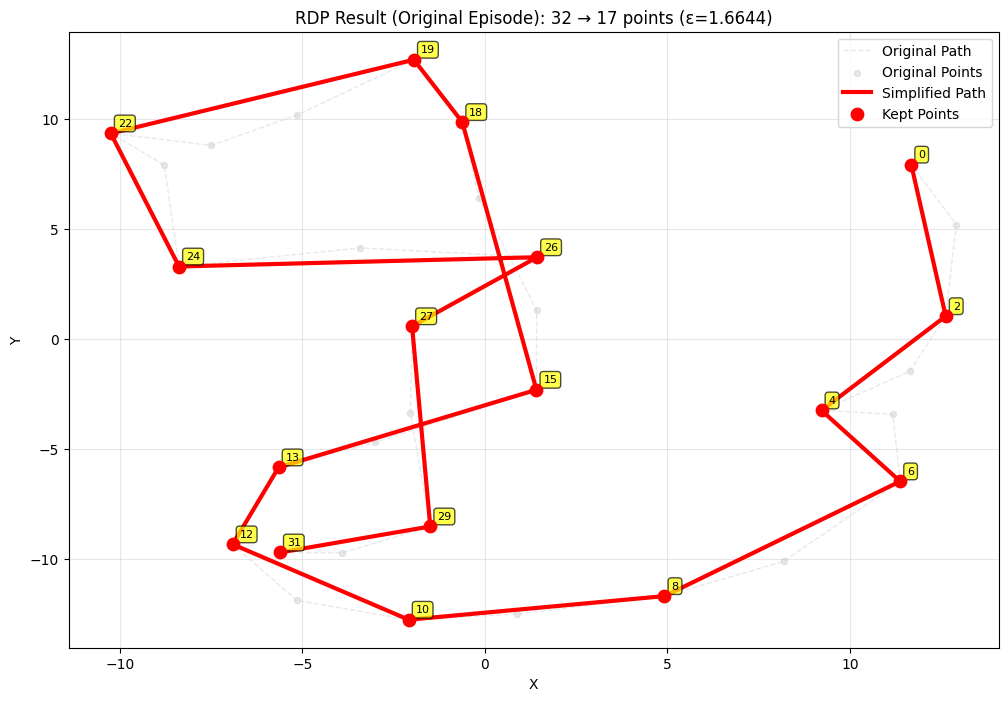


Summary:
- Original trajectory had 32 points
- RDP simplified it to 17 points
- Kept event indices: [0, 2, 4, 6, 8, 10, 12, 13, 15, 18, 19, 22, 24, 26, 27, 29, 31]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Go to folder
os.chdir(r"C:\Users\Alishba\Downloads\prediction files\Transcriptions\Trajectory Analysis\k50 embeddings")
events = np.load("atlep1-events.npy")
print('Events Shape:', events.shape)

def calculate_perpendicular_distance(point, line_start, line_end):
    """Calculate perpendicular distance from point to line"""
    x0, y0 = point
    x1, y1 = line_start
    x2, y2 = line_end
    
    # Handle case where line_start and line_end are the same
    if x1 == x2 and y1 == y2:
        return np.sqrt((x0-x1)**2 + (y0-y1)**2)
    
    distance = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    return distance

def find_farthest_point(points, start_idx, end_idx):
    """Find the point farthest from the line between start and end points"""
    if end_idx - start_idx <= 1:
        return -1, 0
    
    line_start = points[start_idx]
    line_end = points[end_idx]
    
    max_distance = 0
    farthest_idx = -1
    
    for i in range(start_idx + 1, end_idx):
        distance = calculate_perpendicular_distance(points[i], line_start, line_end)
        if distance > max_distance:
            max_distance = distance
            farthest_idx = i
    
    return farthest_idx, max_distance

def rdp_recursive(points, start_idx, end_idx, epsilon, kept_indices):
    """Recursive RDP algorithm"""
    print(f"Processing segment: {start_idx} to {end_idx}")
    
    # Find farthest point
    farthest_idx, max_distance = find_farthest_point(points, start_idx, end_idx)
    
    print(f"  Farthest point: {farthest_idx}, Distance: {max_distance:.4f}, Epsilon: {epsilon:.4f}")
    
    # If distance is greater than epsilon, keep the point and recurse
    if farthest_idx != -1 and max_distance > epsilon:
        print(f"  Keeping point {farthest_idx}")
        kept_indices.append(farthest_idx)
        
        # Recursively process the two segments
        rdp_recursive(points, start_idx, farthest_idx, epsilon, kept_indices)
        rdp_recursive(points, farthest_idx, end_idx, epsilon, kept_indices)
    else:
        print(f"  No points to keep in this segment")

# Step 1: Find the initial farthest point 
print("\n=== STEP 1: Initial Analysis ===")
x1, y1 = events[0]
x2, y2 = events[-1]

distances = []
for (x0, y0) in events:
    d = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    distances.append(d)
distances = np.array(distances)

farthest_idx = np.argmax(distances)
max_distance = distances[farthest_idx]
print(f"Initial farthest point: Event #{farthest_idx}, Distance: {max_distance:.4f}")

# Step 2: Visualize the split
print("\n=== STEP 2: Visualizing the Split ===")
plt.figure(figsize=(12, 8))

# Plot original trajectory
plt.plot(events[:, 0], events[:, 1], color="lightblue", linestyle="--", alpha=0.7, linewidth=2, label="Original Path")

# Plot the two segments after split
segment1 = events[:farthest_idx+1]
segment2 = events[farthest_idx:]

plt.plot(segment1[:, 0], segment1[:, 1], color="red", linewidth=3, label=f"Segment 1 (0→{farthest_idx})")
plt.plot(segment2[:, 0], segment2[:, 1], color="blue", linewidth=3, label=f"Segment 2 ({farthest_idx}→{len(events)-1})")

# Highlight key points
plt.scatter(events[0, 0], events[0, 1], color="green", s=100, marker="^", label="Start", zorder=5)
plt.scatter(events[-1, 0], events[-1, 1], color="orange", s=100, marker="v", label="End", zorder=5)
plt.scatter(events[farthest_idx, 0], events[farthest_idx, 1], color="purple", s=150, marker="*", label=f"Split Point (#{farthest_idx})", zorder=5)

# Original line from start to end
plt.plot([x1, x2], [y1, y2], color="green", linestyle="-.", linewidth=2, alpha=0.7, label="Start→End Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Trajectory Split at Farthest Point (Event #{farthest_idx})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 3: Apply RDP recursively
print("\n=== STEP 3: Applying RDP Recursively ===")
epsilon = 0.1 * max_distance
print(f"Using epsilon = 0.1 * max_distance = {epsilon:.4f}")

# Keep track of indices that we want to preserve
kept_indices = [0, len(events)-1]  # Always keep start and end points

# Apply RDP recursively
rdp_recursive(events, 0, len(events)-1, epsilon, kept_indices)

# Sort the kept indices
kept_indices.sort()
print(f"\nFinal kept indices: {kept_indices}")
print(f"Original points: {len(events)}, Simplified points: {len(kept_indices)}")
print(f"Compression ratio: {len(kept_indices)/len(events)*100:.1f}%")

# Step 4: Visualize the final result
print("\n=== STEP 4: Final Result ===")
plt.figure(figsize=(12, 8))

# Plot original trajectory
plt.plot(events[:, 0], events[:, 1], color="lightgray", linestyle="--", alpha=0.5, linewidth=1, label="Original Path")
plt.scatter(events[:, 0], events[:, 1], color="lightgray", s=20, alpha=0.5, label="Original Points")

# Plot simplified trajectory
simplified_events = events[kept_indices]
plt.plot(simplified_events[:, 0], simplified_events[:, 1], color="red", linewidth=3, label="Simplified Path")
plt.scatter(simplified_events[:, 0], simplified_events[:, 1], color="red", s=80, label="Kept Points", zorder=5)

# Annotate kept points with their original indices
for i, idx in enumerate(kept_indices):
    plt.annotate(f'{idx}', (events[idx, 0], events[idx, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"RDP Result (Original Episode): {len(events)} → {len(kept_indices)} points (ε={epsilon:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nSummary:")
print(f"- Original trajectory had {len(events)} points")
print(f"- RDP simplified it to {len(kept_indices)} points")
print(f"- Kept event indices: {kept_indices}")

### Ramer Douglas Peucker Algorithm - Compelete Implementation for Prediction events

Events Shape: (32, 2)

=== STEP 1: Initial Analysis ===
Initial farthest point: Event #27, Distance: 12.4466

=== STEP 2: Visualizing the Split ===


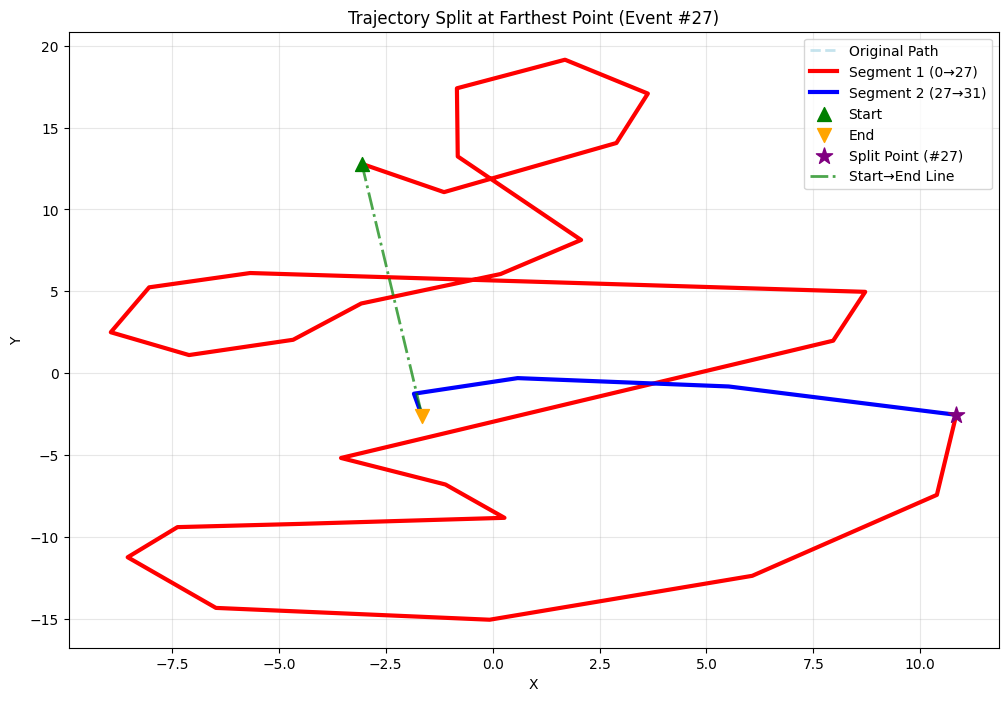


=== STEP 3: Applying RDP Recursively ===
Using epsilon = 0.1 * max_distance = 1.2447
Processing segment: 0 to 31
  Farthest point: 27, Distance: 12.4466, Epsilon: 1.2447
  Keeping point 27
Processing segment: 0 to 27
  Farthest point: 23, Distance: 20.7418, Epsilon: 1.2447
  Keeping point 23
Processing segment: 0 to 23
  Farthest point: 15, Distance: 12.6548, Epsilon: 1.2447
  Keeping point 15
Processing segment: 0 to 15
  Farthest point: 11, Distance: 11.9601, Epsilon: 1.2447
  Keeping point 11
Processing segment: 0 to 11
  Farthest point: 7, Distance: 6.3655, Epsilon: 1.2447
  Keeping point 7
Processing segment: 0 to 7
  Farthest point: 4, Distance: 7.9006, Epsilon: 1.2447
  Keeping point 4
Processing segment: 0 to 4
  Farthest point: 2, Distance: 4.0060, Epsilon: 1.2447
  Keeping point 2
Processing segment: 0 to 2
  Farthest point: 1, Distance: 2.0904, Epsilon: 1.2447
  Keeping point 1
Processing segment: 0 to 1
  Farthest point: -1, Distance: 0.0000, Epsilon: 1.2447
  No points to

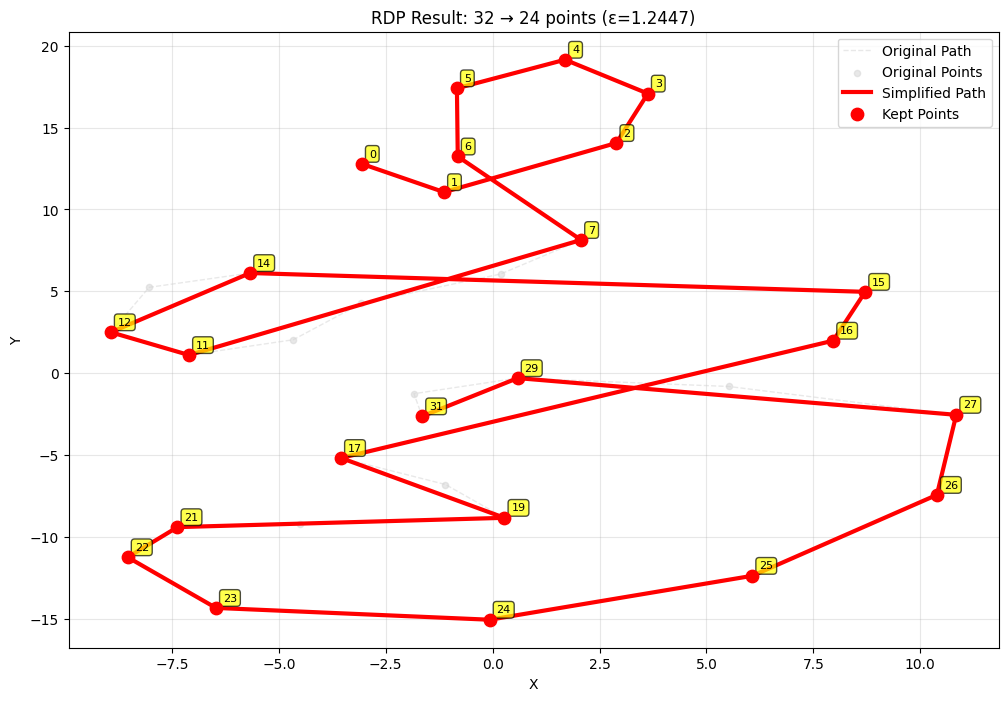


Summary:
- Original trajectory had 32 points
- RDP simplified it to 24 points
- Kept event indices: [0, 1, 2, 3, 4, 5, 6, 7, 11, 12, 14, 15, 16, 17, 19, 21, 22, 23, 24, 25, 26, 27, 29, 31]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Go to folder
os.chdir(r"C:\Users\Alishba\Downloads\prediction files\Transcriptions\Trajectory Analysis\k50 embeddings")
events = np.load("prediction-events.npy")
print('Events Shape:', events.shape)

def calculate_perpendicular_distance(point, line_start, line_end):
    """Calculate perpendicular distance from point to line"""
    x0, y0 = point
    x1, y1 = line_start
    x2, y2 = line_end
    
    # Handle case where line_start and line_end are the same
    if x1 == x2 and y1 == y2:
        return np.sqrt((x0-x1)**2 + (y0-y1)**2)
    
    distance = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    return distance

def find_farthest_point(points, start_idx, end_idx):
    """Find the point farthest from the line between start and end points"""
    if end_idx - start_idx <= 1:
        return -1, 0
    
    line_start = points[start_idx]
    line_end = points[end_idx]
    
    max_distance = 0
    farthest_idx = -1
    
    for i in range(start_idx + 1, end_idx):
        distance = calculate_perpendicular_distance(points[i], line_start, line_end)
        if distance > max_distance:
            max_distance = distance
            farthest_idx = i
    
    return farthest_idx, max_distance

def rdp_recursive(points, start_idx, end_idx, epsilon, kept_indices):
    """Recursive RDP algorithm"""
    print(f"Processing segment: {start_idx} to {end_idx}")
    
    # Find farthest point
    farthest_idx, max_distance = find_farthest_point(points, start_idx, end_idx)
    
    print(f"  Farthest point: {farthest_idx}, Distance: {max_distance:.4f}, Epsilon: {epsilon:.4f}")
    
    # If distance is greater than epsilon, keep the point and recurse
    if farthest_idx != -1 and max_distance > epsilon:
        print(f"  Keeping point {farthest_idx}")
        kept_indices.append(farthest_idx)
        
        # Recursively process the two segments
        rdp_recursive(points, start_idx, farthest_idx, epsilon, kept_indices)
        rdp_recursive(points, farthest_idx, end_idx, epsilon, kept_indices)
    else:
        print(f"  No points to keep in this segment")

# Step 1: Find the initial farthest point 
print("\n=== STEP 1: Initial Analysis ===")
x1, y1 = events[0]
x2, y2 = events[-1]

distances = []
for (x0, y0) in events:
    d = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1) / np.sqrt((y2-y1)**2 + (x2-x1)**2)
    distances.append(d)
distances = np.array(distances)

farthest_idx = np.argmax(distances)
max_distance = distances[farthest_idx]
print(f"Initial farthest point: Event #{farthest_idx}, Distance: {max_distance:.4f}")

# Step 2: Visualize the split
print("\n=== STEP 2: Visualizing the Split ===")
plt.figure(figsize=(12, 8))

# Plot original trajectory
plt.plot(events[:, 0], events[:, 1], color="lightblue", linestyle="--", alpha=0.7, linewidth=2, label="Original Path")

# Plot the two segments after split
segment1 = events[:farthest_idx+1]
segment2 = events[farthest_idx:]

plt.plot(segment1[:, 0], segment1[:, 1], color="red", linewidth=3, label=f"Segment 1 (0→{farthest_idx})")
plt.plot(segment2[:, 0], segment2[:, 1], color="blue", linewidth=3, label=f"Segment 2 ({farthest_idx}→{len(events)-1})")

# Highlight key points
plt.scatter(events[0, 0], events[0, 1], color="green", s=100, marker="^", label="Start", zorder=5)
plt.scatter(events[-1, 0], events[-1, 1], color="orange", s=100, marker="v", label="End", zorder=5)
plt.scatter(events[farthest_idx, 0], events[farthest_idx, 1], color="purple", s=150, marker="*", label=f"Split Point (#{farthest_idx})", zorder=5)

# Original line from start to end
plt.plot([x1, x2], [y1, y2], color="green", linestyle="-.", linewidth=2, alpha=0.7, label="Start→End Line")

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Trajectory Split at Farthest Point (Event #{farthest_idx})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 3: Apply RDP recursively
print("\n=== STEP 3: Applying RDP Recursively ===")
epsilon = 0.1 * max_distance
print(f"Using epsilon = 0.1 * max_distance = {epsilon:.4f}")

# Keep track of indices that we want to preserve
kept_indices = [0, len(events)-1]  # Always keep start and end points

# Apply RDP recursively
rdp_recursive(events, 0, len(events)-1, epsilon, kept_indices)

# Sort the kept indices
kept_indices.sort()
print(f"\nFinal kept indices: {kept_indices}")
print(f"Original points: {len(events)}, Simplified points: {len(kept_indices)}")
print(f"Compression ratio: {len(kept_indices)/len(events)*100:.1f}%")

# Step 4: Visualize the final result
print("\n=== STEP 4: Final Result ===")
plt.figure(figsize=(12, 8))

# Plot original trajectory
plt.plot(events[:, 0], events[:, 1], color="lightgray", linestyle="--", alpha=0.5, linewidth=1, label="Original Path")
plt.scatter(events[:, 0], events[:, 1], color="lightgray", s=20, alpha=0.5, label="Original Points")

# Plot simplified trajectory
simplified_events = events[kept_indices]
plt.plot(simplified_events[:, 0], simplified_events[:, 1], color="red", linewidth=3, label="Simplified Path")
plt.scatter(simplified_events[:, 0], simplified_events[:, 1], color="red", s=80, label="Kept Points", zorder=5)

# Annotate kept points with their original indices
for i, idx in enumerate(kept_indices):
    plt.annotate(f'{idx}', (events[idx, 0], events[idx, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"RDP Result: {len(events)} → {len(kept_indices)} points (ε={epsilon:.4f})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nSummary:")
print(f"- Original trajectory had {len(events)} points")
print(f"- RDP simplified it to {len(kept_indices)} points")
print(f"- Kept event indices: {kept_indices}")